<a href="https://colab.research.google.com/github/npandolfi/Chicago-Red-Light-Camera-Policy-Effects/blob/main/ChicagoRedLightCameras.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This project investigates the causal impact of the 2017 red light camera deactivations on municipal revenue in Chicago. It employs a Difference-in-Differences (DiD) framework to isolate the treatment effect of the policy change. To mitigate selection bias inherent in camera placement, Propensity Score Matching (PSM) is used to construct a credible counterfactual. The analysis quantifies the trade-off between policy-driven decommission and city revenue.

## Install Libraries & Import Data

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.cm as cm
import seaborn as sns
import folium
from folium.plugins import HeatMap
from datetime import datetime
import statsmodels.formula.api as smf
from sklearn.neighbors import NearestNeighbors

Data is from the city of chicago website

In [6]:
locations = pd.read_csv('/content/drive/MyDrive/Data Science Projects/Red Light Camera Revenue/Red_Light_Camera_Locations_20260303.csv')
violations = pd.read_csv('/content/drive/MyDrive/Data Science Projects/Red Light Camera Revenue/Red_Light_Camera_Violations_20260303.csv')

## Evalulate Datasets

### Locations Data

In [7]:
locations.head()

,INTERSECTION,FIRST APPROACH,SECOND APPROACH,THIRD APPROACH,GO LIVE DATE,LATITUDE,LONGITUDE,LOCATION
0,2400 W Marquette Road,WB,NaN,NaN,11/28/2008,41.77207,-87.68299,"(41.77207, -87.68299)"
1,6700 S Western Ave,SB,NaN,NaN,11/28/2008,41.77227,-87.68364,"(41.77227, -87.68364)"
2,6400 N Western Ave,SB,NaN,NaN,07/29/2008,41.99803,-87.68997,"(41.99803, -87.68997)"
3,7900 S Stony Island Ave,SB,NaN,NaN,05/05/2007,41.75203,-87.5859,"(41.75203, -87.5859)"
4,7901 S Western Ave,NB,NaN,NaN,05/05/2007,41.74973,-87.6827,"(41.74973, -87.6827)"


In [8]:
locations.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   INTERSECTION     300 non-null    object 
 1   FIRST APPROACH   300 non-null    object 
 2   SECOND APPROACH  0 non-null      float64
 3   THIRD APPROACH   0 non-null      float64
 4   GO LIVE DATE     300 non-null    object 
 5   LATITUDE         300 non-null    float64
 6   LONGITUDE        300 non-null    object 
 7   LOCATION         300 non-null    object 
dtypes: float64(3), object(5)
memory usage: 18.9+ KB


#### Locations Heatmap

Generate interactive heatmaps to visualize the spatial density of the red light program. Weight coordinates by installation age to identify longitudinal rollout patterns across Chicago's wards.

In [15]:
# Prep location data
locations['GO LIVE DATE'] = pd.to_datetime(locations['GO LIVE DATE'])
locations['year_installed'] = locations['GO LIVE DATE'].dt.year

# Create a normalized weight based on year (Older = Higher Weight for Heatmap)
min_year, max_year = locations['year_installed'].min(), locations['year_installed'].max()
locations['weight'] = (max_year - locations['year_installed']) / (max_year - min_year)

# Initialize the Map, centered on Chicago (The Loop)
m = folium.Map(location=[41.8781, -87.6298], zoom_start=11, tiles='CartoDB positron')

# Add the HeatMap Layer
# This creates the "glow" around dense/old installation areas
heat_data = locations[['LATITUDE', 'LONGITUDE', 'weight']].values.tolist()
HeatMap(heat_data, radius=15, blur=20, min_opacity=0.4).add_to(m)

# Add Color-Coded Circle Markers
# Red = Oldest (2000s), Blue = Newest (2020s)
colormap = cm.get_cmap('RdYlBu') # Red-Yellow-Blue

for _, row in locations.iterrows():
    # Normalize year to 0-1 for the colormap
    norm_year = (row['year_installed'] - min_year) / (max_year - min_year)
    color_hex = colors.to_hex(colormap(1 - norm_year)) # Invert so Red is old

    folium.CircleMarker(
        location=[row['LATITUDE'], row['LONGITUDE']],
        radius=4,
        color=color_hex,
        fill=True,
        fill_opacity=0.8,
        tooltip=f"Intersection: {row['INTERSECTION']}<br>Installed: {row['year_installed']}"
    ).add_to(m)

# Display the Map (This line prints it in the notebook)
m

/tmp/ipykernel_334/3062514750.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('RdYlBu') # Red-Yellow-Blue


### Violations Data

In [18]:
violations.head(10)

,INTERSECTION,CAMERA ID,ADDRESS,VIOLATION DATE,VIOLATIONS,X COORDINATE,Y COORDINATE,LATITUDE,LONGITUDE,LOCATION,MONTH
0,111TH AND HALSTED,2422.0,11100 S HALSTED ST,2026-02-17,2,1.172924e+06,1.831209e+06,41.692263,-87.642523,"(41.692263123425136, -87.6425226876268)",2026-02-01
1,119TH AND HALSTED,2402.0,11900 S HALSTED,2026-02-17,7,1.173095e+06,1.825911e+06,41.677721,-87.642052,"(41.67772082924762, -87.64205184498218)",2026-02-01
2,31ST ST AND MARTIN LUTHER KING DRIVE,2121.0,3100 S DR MARTIN L KING,2026-02-17,15,NaN,NaN,NaN,NaN,NaN,2026-02-01
3,31ST ST AND MARTIN LUTHER KING DRIVE,2123.0,400 E 31ST STREET,2026-02-17,2,1.179438e+06,1.884566e+06,41.838534,-87.617046,"(41.838534018118914, -87.61704611345726)",2026-02-01
4,35TH AND WESTERN,2092.0,3500 S WESTERN,2026-02-17,2,1.160895e+06,1.881377e+06,41.830187,-87.685178,"(41.83018725526863, -87.68517792510231)",2026-02-01
5,35TH AND WESTERN,2091.0,3500 S WESTERN,2026-02-17,2,1.160895e+06,1.881377e+06,41.830187,-87.685178,"(41.83018725526863, -87.68517792510231)",2026-02-01
6,4700 WESTERN,2141.0,4700 S WESTERN AVENUE,2026-02-17,4,1.161120e+06,1.873431e+06,41.808378,-87.684571,"(41.808378407946726, -87.68457071689552)",2026-02-01
7,4700 WESTERN,2142.0,4700 S WESTERN AVENUE,2026-02-17,1,1.161120e+06,1.873431e+06,41.808378,-87.684571,"(41.808378407946726, -87.68457071689552)",2026-02-01
8,55TH AND KEDZIE,2162.0,5500 S KEDZIE AVENUE,2026-02-17,2,1.155946e+06,1.867942e+06,41.793420,-87.703698,"(41.793420236755864, -87.70369750845424)",2026-02-01
9,55TH AND KEDZIE,2163.0,3200 W 55TH STREET,2026-02-17,4,1.155967e+06,1.868016e+06,41.793623,-87.703618,"(41.79362280329978, -87.70361814062049)",2026-02-01


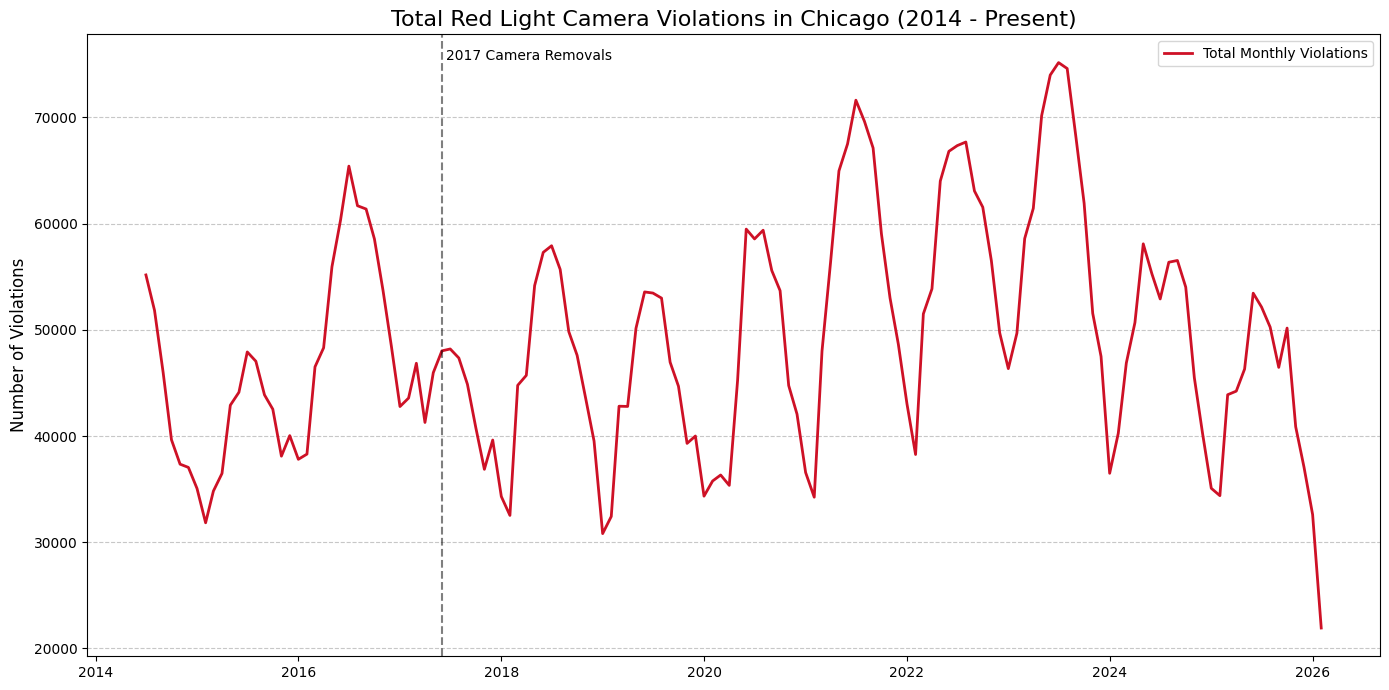

In [54]:
# Clean and Prepare
violations['VIOLATION DATE'] = pd.to_datetime(violations['VIOLATION DATE'])
violations['MONTH'] = violations['VIOLATION DATE'].dt.to_period('M').dt.to_timestamp()

# Aggregate Violations by Month
# This smooths out daily noise so we can see the macro trends
monthly_violations = violations.groupby('MONTH')['VIOLATIONS'].sum().reset_index()

# 3. Create the Plot
plt.figure(figsize=(14, 7))
plt.plot(monthly_violations['MONTH'], monthly_violations['VIOLATIONS'],
         color='#ce1126', linewidth=2, label='Total Monthly Violations')

# Annotate the 2017 Removal period for context
plt.axvline(pd.to_datetime('2017-06-01'), color='black', linestyle='--', alpha=0.5)
plt.text(pd.to_datetime('2017-06-15'), monthly_violations['VIOLATIONS'].max(),
         '2017 Camera Removals', rotation=0, verticalalignment='bottom')

plt.title('Total Red Light Camera Violations in Chicago (2014 - Present)', fontsize=16)
plt.ylabel('Number of Violations', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()

plt.show()

#### Estimating the Effect of Camera Removal (Diff-in-Diff)

Based on the city's historical data, here are the intersections that were removed in March 2017.

In [20]:
# List of intersections removed in March 2017
removed_intersections = [
    '95TH AND STONY ISLAND',
    '71ST AND WESTERN',
    'WESTERN AND PERSHING',
    'GRAND AND OAK PARK',
    'IRVING PARK AND KEDZIE',
    'PETERSON AND PULASKI'
]

##### Standard Diff-in-Diff

We need to create two "Dummy" (Binary) variables for DiD modeling. To do this we construct a balanced panel dataset by re-indexing the time-series. Force zero-value entries for decommissioned intersections to ensure the model captures the drop to zero revenue post-treatment.

In [55]:
# Pre-process and Filter using .query()
df_did = (violations
    .assign(VIOLATION_DATE=pd.to_datetime(violations['VIOLATION DATE']))
    .query("'2016-01-01' <= VIOLATION_DATE <= '2018-12-31'")
    .assign(MONTH=lambda x: x['VIOLATION_DATE'].dt.to_period('M').dt.to_timestamp())
)

# Aggregate to Monthly
panel_data = (df_did
    .groupby(['INTERSECTION', 'MONTH'])['VIOLATIONS']
    .sum()
    .reset_index()
)

# Build the Full Grid to ensure we don't drop intersections that were removed
full_index = pd.MultiIndex.from_product(
    [panel_data['INTERSECTION'].unique(), panel_data['MONTH'].unique()],
    names=['INTERSECTION', 'MONTH']
)

# Re-index and Assign DiD Logic in one pass
# We wait until the very end to assign indicators so we only do it once
panel_full = (panel_data
    .set_index(['INTERSECTION', 'MONTH'])
    .reindex(full_index, fill_value=0)
    .reset_index()
    .assign(
        is_treated = lambda x: x['INTERSECTION'].isin(removed_intersections).astype(int),
        is_post    = lambda x: (x['MONTH'] >= '2017-06-01').astype(int),
        did_interaction = lambda x: x['is_treated'] * x['is_post']
    )
)

In [56]:
panel_full.head()

,INTERSECTION,MONTH,VIOLATIONS,is_treated,is_post,did_interaction
0,111TH AND HALSTED,2016-01-01,252,0,0,0
1,111TH AND HALSTED,2016-02-01,261,0,0,0
2,111TH AND HALSTED,2016-03-01,311,0,0,0
3,111TH AND HALSTED,2016-04-01,298,0,0,0
4,111TH AND HALSTED,2016-05-01,447,0,0,0


Now we run the regression model to estimate the effect

In [57]:
# Simple Ordinary Least Squares for the Differences in Differences effect
model = smf.ols(formula='VIOLATIONS ~ is_treated + is_post + did_interaction', data=panel_full)
results = model.fit()

print(results.summary())

                            OLS Regression Results                            
Dep. Variable:             VIOLATIONS   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                  0.006
Method:                 Least Squares   F-statistic:                     13.13
Date:                Wed, 04 Mar 2026   Prob (F-statistic):           1.52e-08
Time:                        03:23:31   Log-Likelihood:                -41400.
No. Observations:                5724   AIC:                         8.281e+04
Df Residuals:                    5720   BIC:                         8.283e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept         317.0360      6.484     

Evaluate if the Parallel Trends Assumption holds true

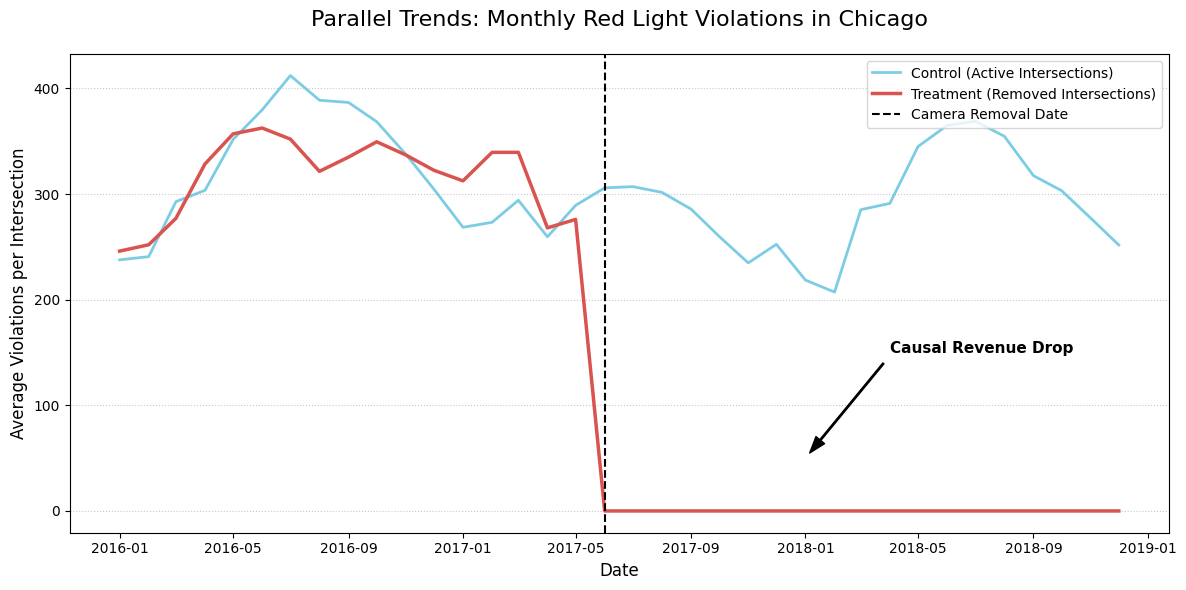

In [58]:
# Calculate the monthly mean violations for each group
trends = panel_full.groupby(['MONTH', 'is_treated'])['VIOLATIONS'].mean().unstack()

# Create the Plot
plt.figure(figsize=(12, 6), dpi=100)

# Plot Control Group (is_treated = 0)
plt.plot(trends.index, trends[0], label='Control (Active Intersections)',
         color='#5bc0de', linewidth=2, alpha=0.8)

# Plot Treatment Group (is_treated = 1)
plt.plot(trends.index, trends[1], label='Treatment (Removed Intersections)',
         color='#d9534f', linewidth=2.5)

# Add the Intervention Line (June 2017)
plt.axvline(pd.to_datetime('2017-06-01'), color='black', linestyle='--',
            linewidth=1.5, label='Camera Removal Date')

# Formatting
plt.title('Parallel Trends: Monthly Red Light Violations in Chicago', fontsize=16, pad=20)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Average Violations per Intersection', fontsize=12)
plt.legend(frameon=True, facecolor='white', loc='upper right')
plt.grid(axis='y', linestyle=':', alpha=0.7)

# Highlight the Gap
plt.annotate('Causal Revenue Drop',
             xy=(pd.to_datetime('2018-01-01'), 50),
             xytext=(pd.to_datetime('2018-04-01'), 150),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=8),
             fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

##### Propensity Score Matching for Diff-in-Diff

Parallel Trends clearly doesn't hold true so lets try propensity score matching. We implement a 3-Nearest Neighbor matching algorithm based on pre-period violation volume. This creates a control group of active intersections that share a similar baseline with the treatment group.

In [59]:
# Create a "Pre-Period" summary for matching
# We match based on behavior BEFORE the 2017 event (all of 2016)
pre_event_stats = (panel_full
    .query("MONTH < '2017-06-01'")
    .groupby('INTERSECTION')
    .agg({
        'VIOLATIONS': 'mean',
        'is_treated': 'max' # 1 for treated, 0 for control
    })
    .reset_index()
)

# Separate Treatment and Control Pools
treated_pool = pre_event_stats.query("is_treated == 1")
control_pool = pre_event_stats.query("is_treated == 0")

# Find the "Best Matches"
# We'll find the 3 control intersections that most closely match each treated intersection's volume
nn = NearestNeighbors(n_neighbors=3, metric='euclidean')
nn.fit(control_pool[['VIOLATIONS']]) # Matching on average violation volume

distances, indices = nn.kneighbors(treated_pool[['VIOLATIONS']])

# Get the names of the matched control intersections
matched_control_intersections = control_pool.iloc[indices.flatten()]['INTERSECTION'].unique()

# Filter the main dataset to ONLY include Treated and their Matched Controls
# This is your "Matched Panel"
matched_panel = panel_full[
    panel_full['INTERSECTION'].isin(list(removed_intersections) + list(matched_control_intersections))
].copy()

Re-run Diff in Diff

In [60]:
model_psm = smf.ols(
    formula='VIOLATIONS ~ is_treated + is_post + did_interaction',
    data=matched_panel
)
results_psm = model_psm.fit()

print(results_psm.summary())

                            OLS Regression Results                            
Dep. Variable:             VIOLATIONS   R-squared:                       0.557
Model:                            OLS   Adj. R-squared:                  0.553
Method:                 Least Squares   F-statistic:                     119.2
Date:                Wed, 04 Mar 2026   Prob (F-statistic):           5.40e-50
Time:                        03:24:08   Log-Likelihood:                -1725.9
No. Observations:                 288   AIC:                             3460.
Df Residuals:                     284   BIC:                             3474.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept         316.6471      9.663     

Re-evaluate Parallel Trends Assumption

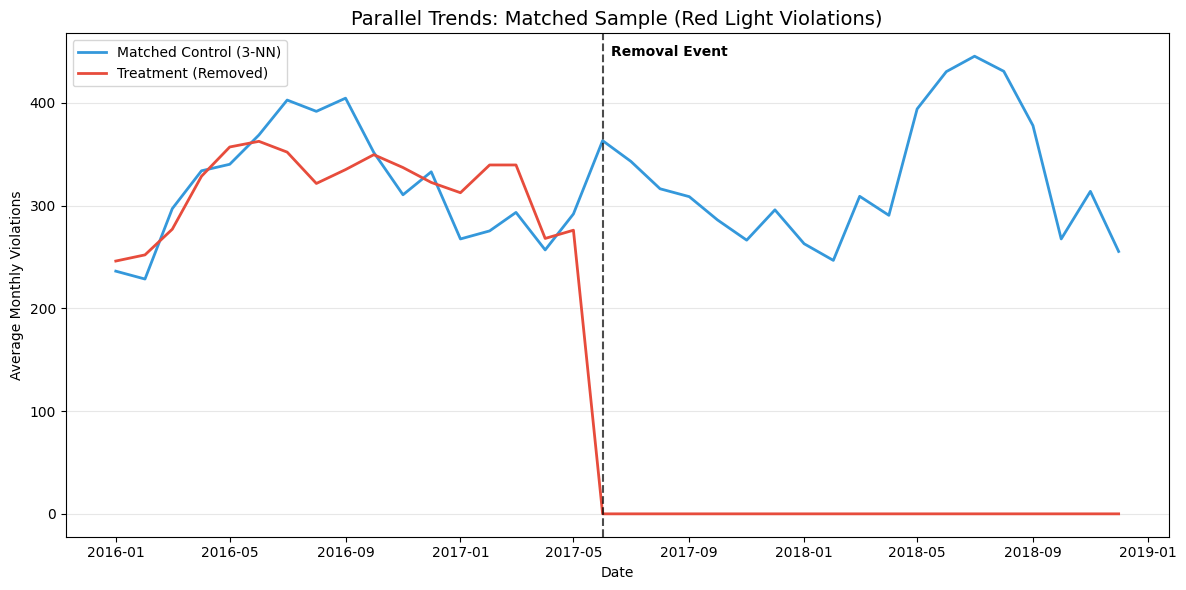

In [61]:
# Calculate the monthly means for the Matched Groups
matched_trends = matched_panel.groupby(['MONTH', 'is_treated'])['VIOLATIONS'].mean().unstack()

plt.figure(figsize=(12, 6), dpi=100)

# Plotting the two lines
plt.plot(matched_trends.index, matched_trends[0], label='Matched Control (3-NN)', color='#3498db', linewidth=2)
plt.plot(matched_trends.index, matched_trends[1], label='Treatment (Removed)', color='#e74c3c', linewidth=2)

# Marking the event
plt.axvline(pd.to_datetime('2017-06-01'), color='black', linestyle='--', alpha=0.7)
plt.text(pd.to_datetime('2017-06-10'), matched_trends[0].max(), 'Removal Event', fontweight='bold')

plt.title('Parallel Trends: Matched Sample (Red Light Violations)', fontsize=14)
plt.ylabel('Average Monthly Violations')
plt.xlabel('Date')
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

###### Quantitative Evaluation

Placebo Evaluation: This is a robustness check designed to validate the parallel trends assumption. It involves isolating the pre-treatment period (prior to June 2017) and assigning a "fake" treatment date, such as July 1, 2016.

By running the Difference-in-Differences model on this window, the goal is to observe a non-significant interaction coefficient (p>0.05).

A null result confirms that the treatment and control groups were moving in sync before the actual policy change, ensuring that the observed impact in the main analysis is not due to pre-existing diverging trends.

In [62]:
# Filter for ONLY the pre-treatment period (e.g., 2016)
df_placebo = matched_panel.query("MONTH < '2017-06-01'").copy()

# Create a "Fake" treatment date (e.g., July 1, 2016)
df_placebo['is_post_fake'] = (df_placebo['MONTH'] >= '2016-07-01').astype(int)
df_placebo['did_placebo'] = df_placebo['is_treated'] * df_placebo['is_post_fake']

# Run the model
placebo_results = smf.ols('VIOLATIONS ~ is_treated + is_post_fake + did_placebo',
                          data=df_placebo).fit(cov_type='HC3')

print(f"Placebo P-Value: {placebo_results.pvalues['did_placebo']:.4f}")

Placebo P-Value: 0.8921


Time Event Study: We perform a leads-and-lags event study to quantitatively verify the parallel trends assumption. Confirm that the treatment and control groups track identically prior to the June 2017 intervention.

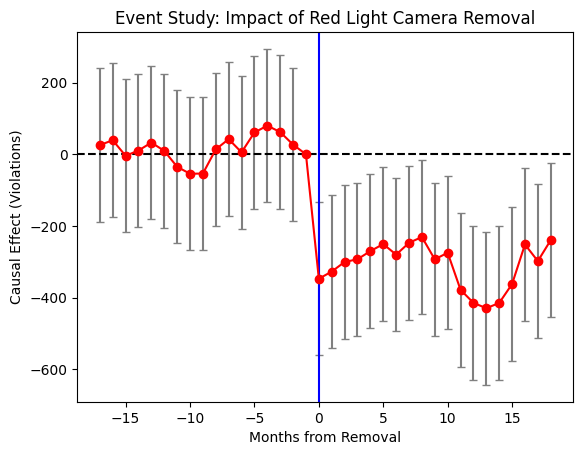

In [68]:

# Create a "Relative Month" column (Distance from June 2017)
matched_panel['rel_month'] = (matched_panel['MONTH'].dt.year - 2017) * 12 + (matched_panel['MONTH'].dt.month - 6)

# Run the Event Study Regression
# We use C(rel_month, Treatment(-1)) to set the baseline to the month before the event
model_ev = smf.ols('VIOLATIONS ~ is_treated * C(rel_month, Treatment(-1))', data=matched_panel).fit()

# Extract and Plot the Coefficients for the Interaction terms
# These represent the 'Difference' between groups at each month
ev_df = pd.DataFrame({
    'month': range(matched_panel.rel_month.min(), matched_panel.rel_month.max() + 1),
    'coef': [model_ev.params.get(f'is_treated:C(rel_month, Treatment(-1))[T.{m}]', 0) for m in range(matched_panel.rel_month.min(), matched_panel.rel_month.max() + 1)],
    'err': [model_ev.bse.get(f'is_treated:C(rel_month, Treatment(-1))[T.{m}]', 0) * 1.96 for m in range(matched_panel.rel_month.min(), matched_panel.rel_month.max() + 1)]
})

plt.errorbar(ev_df.month, ev_df.coef, yerr=ev_df.err, fmt='o-', color='red', ecolor='gray', capsize=3)
plt.axhline(0, color='black', linestyle='--')
plt.axvline(0, color='blue', label='Event (June 2017)')
plt.title("Event Study: Impact of Red Light Camera Removal")
plt.xlabel("Months from Removal")
plt.ylabel("Causal Effect (Violations)")
plt.show()

## Economic Impact

We wrap the research by translating the model coefficients into an annual revenue impact statemen and provide a point estimate and a 95% confidence interval for total municipal revenue loss.

In [66]:
# Constants from our specific model output
coef = -233.88
std_err = 36.16
fine = 100
n_intersections = 6

# Calculations
monthly_loss = coef * fine * n_intersections
annual_loss = monthly_loss * 12
lower_bound_annual = (coef - (1.96 * std_err)) * fine * n_intersections * 12
upper_bound_annual = (coef + (1.96 * std_err)) * fine * n_intersections * 12

print(f"--- CHICAGO RED LIGHT CAMERA REVENUE ANALYSIS ---")
print(f"Total Annual Revenue Impact: ${annual_loss:,.2f}")
print(f"95% Confidence Interval: [${lower_bound_annual:,.2f}, ${upper_bound_annual:,.2f}]")

--- CHICAGO RED LIGHT CAMERA REVENUE ANALYSIS ---
Total Annual Revenue Impact: $-1,683,936.00
95% Confidence Interval: [$-2,194,225.92, $-1,173,646.08]
